<a href="https://colab.research.google.com/github/Perla-Soleith/ProyectoFinalProbabilidad/blob/main/Pr%C3%A1cticaFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Probabilidad y estadistica***

#### 2YY

### Unidad VI Proyecto Final

### 25 de Mayo de 2026

### **INTEGRANTES**



### Perla Soleith Moreno Pérez
### Diego Rodriguez Rochin

### **Docente**
###José Gabriel Rodriguez Rivas
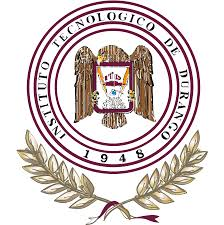

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:

from google.colab import drive
drive.mount('/content/drive')

Ruta = ('/content/drive/MyDrive/covid19.csv')

df = pd.read_csv(Ruta, low_memory=False)
#df = df.sample(frac=0.1, random_state=42)   # Comentar/borrar esta linea para usar todos los datos



Mounted at /content/drive


#***Estadística Descriptiva***

♦ Número de casos positivos, negativos y pendientes de resultado

In [3]:

print("\nResultado del diagnóstico:")
print(df['RESULTADO_ANTIGENO'].value_counts())


Resultado del diagnóstico:
RESULTADO_ANTIGENO
Negativo     5853547
Pendiente    5005939
Positivo     1774708
Name: count, dtype: int64


♦ Número de pacientes hospitalizados y ambulatorios

In [4]:

print("\nTipo de paciente (Hospitalizado / Ambulatorio):")
print(df['TIPO_PACIENTE'].value_counts())




Tipo de paciente (Hospitalizado / Ambulatorio):
TIPO_PACIENTE
Ambulatorio      11543303
Hospitalizado     1090891
Name: count, dtype: int64


♦ Cuántas pacientes estaban embarazadas


In [5]:

print("\nPacientes embarazadas:")
print(df['EMBARAZO'].value_counts())




Pacientes embarazadas:
EMBARAZO
No                 6483614
No aplica          5985456
Si                  122583
Se ignora            42529
No especificado         12
Name: count, dtype: int64


♦ Cuántos son indígenas

In [6]:

print("\nPacientes indígenas:")
print(df['INDIGENA'].value_counts())


Pacientes indígenas:
INDIGENA
No                 3665974
No especificado     167182
Si                   35240
Name: count, dtype: int64


###♦ Visualizaciones

♦ Grafica de barras por estado

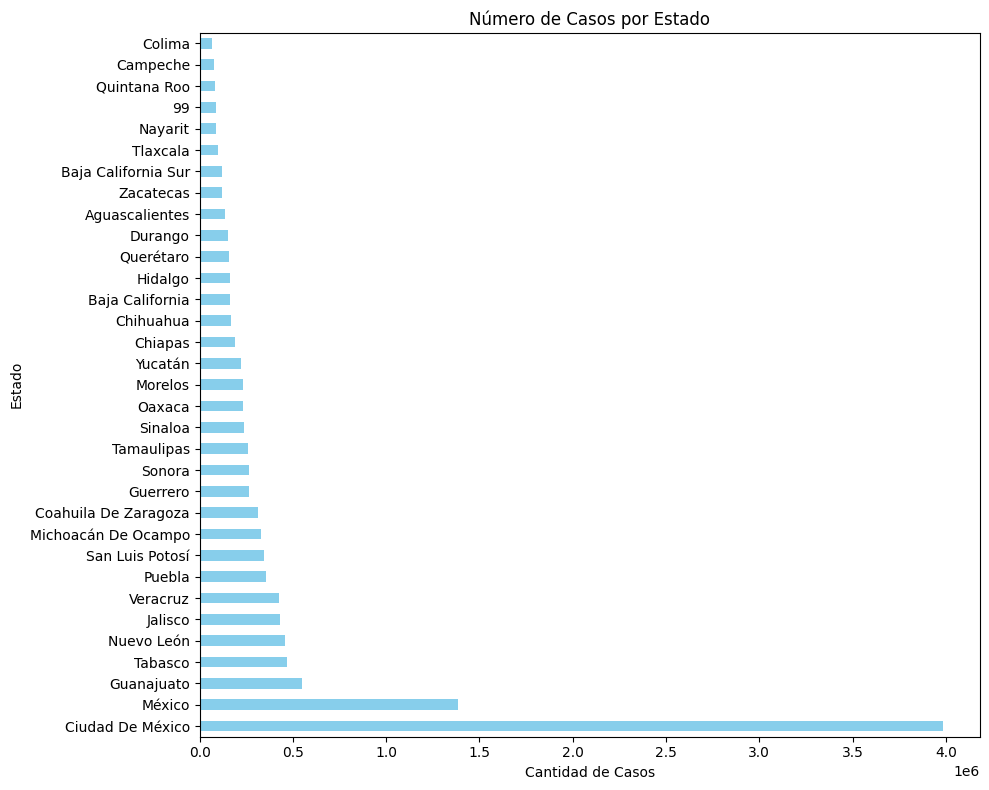

'plt.pyplot.hist(df.ENTIDAD_NAC, bins = 11)\nplt.pyplot.title("Histograma Edad pruebas COVID")\n#plt.pyplot.axvline(media, color=\'y\', linestyle=\'dashed\', linewidth=2, label=f\'Media={media:.2f}\')\nplt.pyplot.xlabel("Edad")\nplt.pyplot.ylabel("Frecuencia")'

In [7]:

plt.figure(figsize=(10, 8))

df['ENTIDAD_NAC'].value_counts().plot(kind='barh', color='skyblue')
plt.title('Número de Casos por Estado')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Estado')
plt.tight_layout()
plt.show()
'''plt.pyplot.hist(df.ENTIDAD_NAC, bins = 11)
plt.pyplot.title("Histograma Edad pruebas COVID")
#plt.pyplot.axvline(media, color='y', linestyle='dashed', linewidth=2, label=f'Media={media:.2f}')
plt.pyplot.xlabel("Edad")
plt.pyplot.ylabel("Frecuencia")'''

♦ Histograma por edad

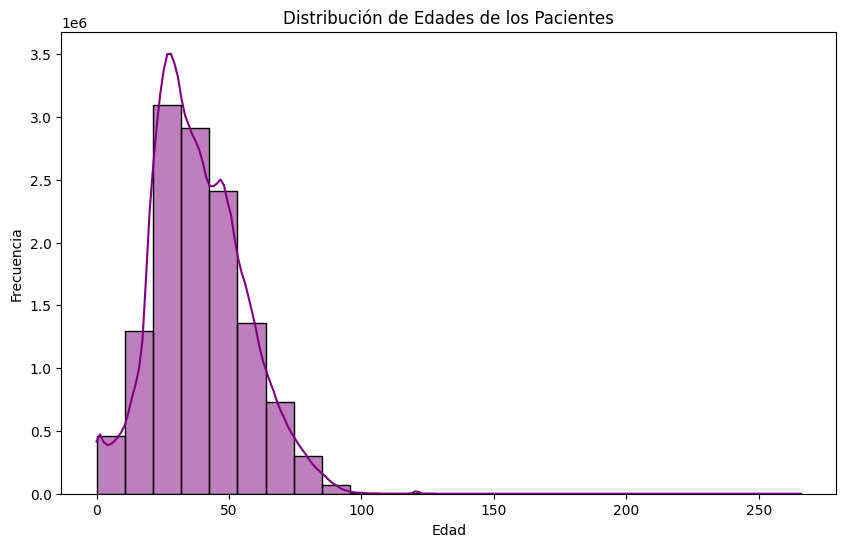

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['EDAD'], bins=25, kde=True, color='purple')
plt.title('Distribución de Edades de los Pacientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

♦ Gráfico por fecha para mostrar la evolución de casos.

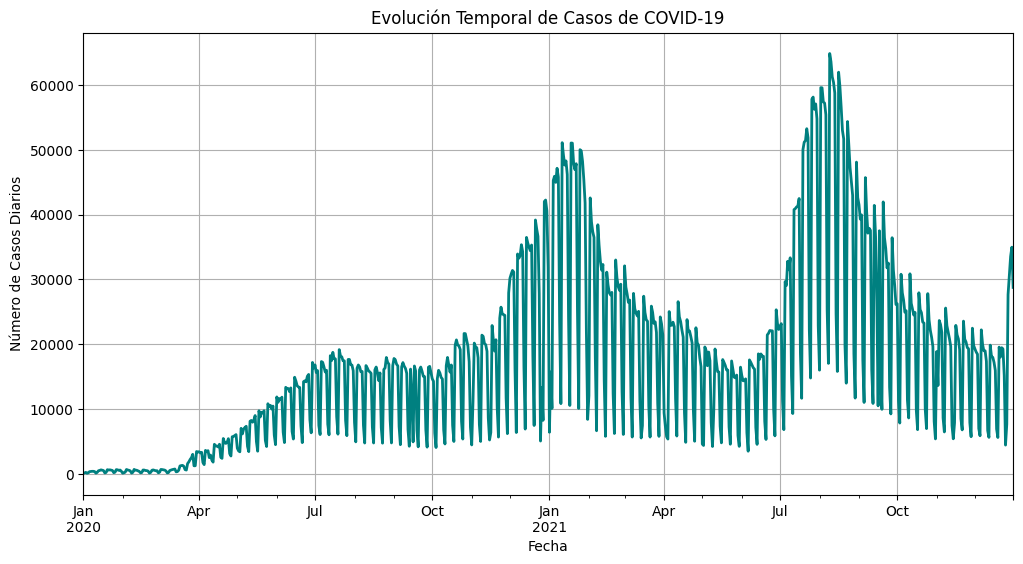

In [9]:

df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'])

casos_por_fecha = df.groupby('FECHA_INGRESO').size()

plt.figure(figsize=(12, 6))
casos_por_fecha.plot(kind='line', color='teal', linewidth=2)
plt.title('Evolución Temporal de Casos de COVID-19')
plt.xlabel('Fecha')
plt.ylabel('Número de Casos Diarios')
plt.grid(True)
plt.show()

♦ Gráfico por sexo y resultado.

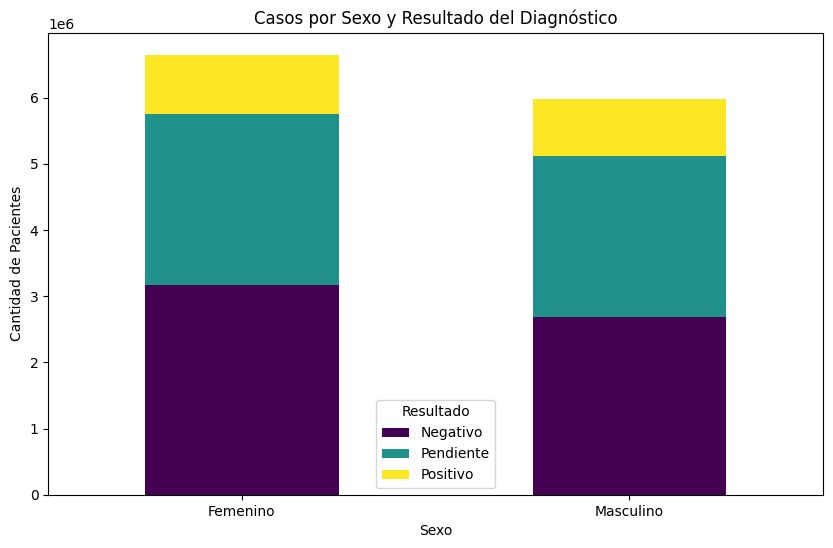

In [10]:
tabla_sexo_resultado = pd.crosstab(df['SEXO'], df['RESULTADO_ANTIGENO'])

tabla_sexo_resultado.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Casos por Sexo y Resultado del Diagnóstico')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Pacientes')
plt.xticks(rotation=0)
plt.legend(title='Resultado')
plt.show()

♦ Gráfico por tipo de paciente

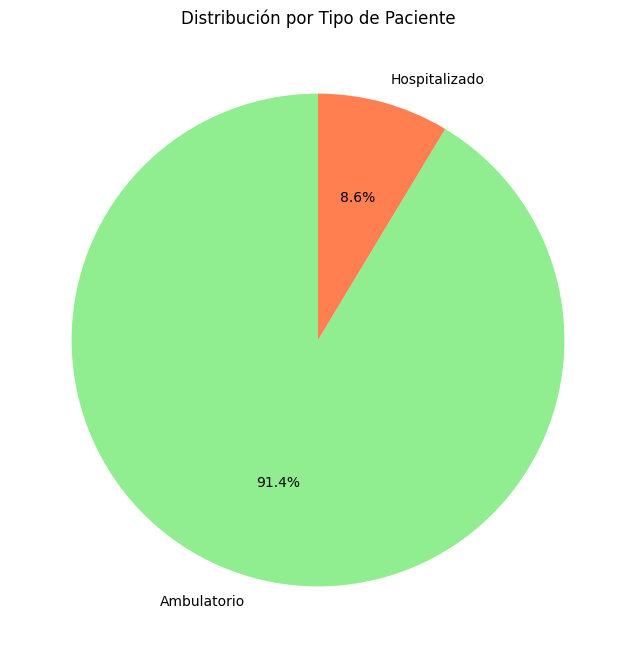

In [11]:
plt.figure(figsize=(8, 8))

df['TIPO_PACIENTE'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'coral'])
plt.title('Distribución por Tipo de Paciente')
plt.ylabel('')
plt.show()

♦ Gráfico por comorbilidad

In [ ]:
comorbilidades = ['DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO']

conteos = [df[df[c] == 'Si'].shape[0] for c in comorbilidades]

plt.figure(figsize=(10, 6))
sns.barplot(x=comorbilidades, y=conteos, palette='magma', hue=comorbilidades, legend=False)
plt.title('Casos de COVID-19 por Comorbilidad')
plt.xlabel('Comorbilidad')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#***Probabilidades por Comorbilidad e interpretación estadística***

In [ ]:

comorbilidades = ['DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD',
     'RENAL_CRONICA', 'TABAQUISMO']


total_general = len(df)
print(f"Total general de registros analizados: {total_general}\n")

###♦ Probabilidad simple

In [ ]:

prob_simples = {}
for comorbilidad in comorbilidades:

    total_comorbilidad = (df[comorbilidad] == 'Si').sum()
    probabilidad = total_comorbilidad / total_general
    prob_simples[comorbilidad] = probabilidad

    print(f"Probabilidad simple de {comorbilidad}: {probabilidad:.2f} ({probabilidad * 100:.2f}%)")

###♦ Probabilidad condicional

In [ ]:

entidades_unicas = df['ENTIDAD_NAC'].unique()

prob_condicionales = {}

for comorbilidad in comorbilidades:
    print(f"\n> Analizando Condicionales para: {comorbilidad}")
    prob_condicionales[comorbilidad] = {}

    for entidad in entidades_unicas:

        df_entidad = df[df['ENTIDAD_NAC'] == entidad]
        total_pacientes_entidad = len(df_entidad)

        if total_pacientes_entidad > 0:

            total_comorbilidad_entidad = (df_entidad[comorbilidad] == 'Si').sum() # Nota: Cambia 'SI' por 1 si aplica

            prob_condicional = total_comorbilidad_entidad / total_pacientes_entidad
        else:
            prob_condicional = 0.0

        prob_condicionales[comorbilidad][entidad] = prob_condicional

        print(f"  P({comorbilidad} | Estado {entidad}): {prob_condicional:.4f} ({prob_condicional * 100:.2f}%)")

###En un análisis de casos positivos de COVID por estado, se observa que el número de casos sigue una distribución normal con:
###• Media: 2360 casos
###• Desviación estándar: 714 casos
###Pregunta: ¿Cuál es la probabilidad de que un estado tenga entre 2000 y 3000 casos positivos?

In [ ]:
from scipy.stats import norm

media = 2360
desviacion_estandar = 714

limite_inferior = 2000
limite_superior = 3000

prob_hasta_3000 = norm.cdf(limite_superior, loc=media, scale=desviacion_estandar)
prob_hasta_2000 = norm.cdf(limite_inferior, loc=media, scale=desviacion_estandar)

probabilidad_final = prob_hasta_3000 - prob_hasta_2000


print(f"Probabilidad de tener entre 2000 y 3000 casos: {probabilidad_final:.4f}")
print(f"En porcentaje: {probabilidad_final * 100:.2f}%")

#***Interpretacion general de resultados***

**Estadística descriptiva**

-Primeramente, en los resultados de los casos de covid, se muestran que hubo mayormente casos negativos, aun que casi iguala a los positivos.

-Casi no se presentaron pacientes hospitalizados, la gran mayoría fue de pacientes ambulatorios.

-Muy pocas mujeres embarazadas confirmadas se hicieron la prueba.

-Una muuuy pequeña cantidad de personas que son indigenas se confirmaron.


**En las visualizaciones:**

-Casi casi todas las personas a las que les hicieron la pruba fueron de Ciudad de méxico.

-En el histograma de las edades, la mayoria fue de aproximadamente entre 20-30 años de edad (Nos sorpredió que hubiera personas con hasta 120 años de edad).

-A lo largo del 2020 no se vieron muchos casos, sin embargo empezó a empeorar la evolución para principios del año 2021 y mucho más entre Julio y octubre del mismo año.

-Por poco, hubo más prubas en personas del género femenino que del masculino, y en ambos casos se vieron más casos negativos.

-Y ccómo se habia mencionado antes, se encontraron más pruebas de personas ambulatorias, y en el grafico circular se puede ver notablemete la diferencia (Menos del 10% de personas hospitalizadas)

-Finalmente en el gráfico de casos por comorbilidad, visiblemente se observa que hubieron mayormente casos con personas con hipertensión y en seguida con obesidad.

**Probabilidad simple:**

-Reafirmando la última gráfica de las comorbilidades, las enfermedades más comunes en los pacientes con sospecha de covid son la hipertensión, la obesidad, la diabetes y el tabaquismo.

**Probabilidad condicional:**

-El riesgo de presentar enfermedades cambia según el estado de México. Zacatecas es el estado que más casos de diabetes e hipertensión, mientras que Sonora, Baja California y Colima tienen mayores niveles de obesidad. Yy finalmente la ciudad de méxico tiene unos de los niveles más elevados de tabaquismo entre los pacientes evaluados.

**Distribución normal:**

-El análisis muestra que existe un porcentaje considerable de probabilidad de registrar entre 2,000 y 3,000 casos diarios aproximadamente. Esto dice que la mayoría del tiempo los contagios se mantuvieron en niveles intermedios.

#***Conclusiones personales***

#Perla Soleith Moreno Pérez
###Lo que aprendí durante el semestre fue a usar la programación de manera más útil para la asignatura, antes de iniciar, a mi sienceramente no se me había cruzado la idea de que se podía aplicar en la probabilidad y la estadística. Y pues considero que los conocimientos que tuvimos nos van a ser de mucha utilidad, ya sea que en algún futuro se quiera organizar información de manera especifíca, e incluso graficarla fácilemnte. Y pues esto aplicaría tanto para sacar valores más siples como las medidas de tendencia central como para dados en los que se tiene muchisma informacion y se puedan calcular las probabilidades que se pueden encontrar para situaciones específicas.

#Diego Rodriguez Rochin
###Durante este semestre aprendí que Python puede ser una herramienta muy bastante útil para analizar datos y no solamente para programar y gracias a las actividades que hicimos durante el semestre, pude entender mejor temas de probabilidad y estadística, ya que los cálculos y las gráficas me dieron mas a comprender y visualizar la información de una forma más clara y sencilla. También aprendí a trabajar con grandes cantidades de datos, obtener medidas estadísticas, calcular probabilidades y representar resultados de manera más útil, pienso que las cosas que vimos serán de gran utilidad en otras materias y en situaciones relacionadas a la carrera donde sea necesario analizar información y tomar decisiones basadas en datos.

